# Spatial Plots - Days

Contributions by Cait Roufa
Includes spatial significance testing with code from A Haberlie: https://github.com/ahaberlie/MCS_Climate/blob/main/examples/stats.py

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import glob
import os
# from copy import deepcopy
# from concurrent.futures import ProcessPoolExecutor
import warnings
# warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib as mpl
from matplotlib.colors import TwoSlopeNorm
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import dask
import stats

In [2]:
# Suppress specific FutureWarning from xarray
warnings.filterwarnings("ignore", message=".*Index.ravel returning ndarray is deprecated.*", category=FutureWarning)

In [3]:
# modified colormaps
base_cmap = plt.cm.OrRd

# mod colormap from OrRd with 0 mapped to transparent
colors_trans = base_cmap(np.linspace(0, 1, 256))
colors_trans[0, -1] = 0  # Make the first color (lowest value, including 0) fully transparent
TrOrRd = ListedColormap(colors_trans)

# mod colormap from OrRd with 0 mapped to white
colors_white = base_cmap(np.linspace(0, 1, 256))
colors_white[0] = [1, 1, 1, 1] # white
WtOrRd = ListedColormap(colors_white)

In [4]:
# define data directory, seasons, and epoch labels
data_dir = '/home/scratch/croufa/syn_sev'
epochs = ['HIST', '4p5MID', '8p5MID', '4p5END', '8p5END']
epoch_labels = ['HIST', 'MID4.5', 'MID8.5', 'END4.5', 'END8.5']
season_months = {
    'DJF': [12, 1, 2],
    'MAM': [3, 4, 5],
    'JJA': [6, 7, 8],
    'SON': [9, 10, 11]
}
seasons = list(season_months.keys())

In [5]:
# function for seasonal climatology
def seasonal_climatology(da, season):
    months = season_months[season]
    da = da.sel(Time=da['Time'].dt.month.isin(months))
    return da.sum(dim='Time')

In [6]:
# load data
ds_all = {}
for epoch in epochs:
    zarr_path = os.path.join(data_dir, f'uvv_{epoch}_combined.zarr')
    ds_all[epoch] = xr.open_zarr(zarr_path)

/home/croufa/.local/lib/python3.9/site-packages/gribapi/__init__.py:23: UserWarning: ecCodes 2.31.0 or higher is recommended. You are running version 2.26.0
  warnings.warn(


In [7]:
# years per epoch
years_per_epoch = {
    epoch: len(np.unique(ds_all[epoch]['Time'].dt.year.values))
    for epoch in epochs
}
print("Years per epoch:", years_per_epoch) # sanity check, should be 16 bc water year

Years per epoch: {'HIST': 16, '4p5MID': 16, '8p5MID': 16, '4p5END': 16, '8p5END': 16}


In [8]:
# builds per-year arrays for sig testing

def seasonal_yearly_counts(da, months):
    """
    da: xr.DataArray with time coord 'Time' and dims (..., south_north, west_east) or (..., lat, lon)
    months: list of ints
    returns DataArray (year, y, x)
    """
    sel = da.sel(Time=da['Time'].dt.month.isin(months))
    # sum within each year
    yr = sel.groupby("Time.year").sum(dim="Time")
    # standardize dim order: (year, y, x)
    # try to detect spatial dims
    dims = dict(zip(yr.dims, yr.shape))
    # Common names in your files
    ydim = 'south_north' if 'south_north' in dims else ('lat' if 'lat' in dims else 'latitude')
    xdim = 'west_east'   if 'west_east'   in dims else ('lon' if 'lon' in dims else 'longitude')
    return yr.transpose("year", ydim, xdim)

In [9]:
# compute seasonal and annual per-year arrays for each epoch for sig testing
# seasonal per-year counts (e.g., 15 x 44 x 69)
season_years_days = {}  # keys: (epoch, season) -> (year, y, x)

for epoch in epochs:
    da = ds_all[epoch]['UVV_DAYS']  # same variable plotted later
    for season in seasons:
        months = season_months[season]
        season_years_days[(epoch, season)] = seasonal_yearly_counts(da, months)

# Annual per-year counts (sum months 1..12 by year)
annual_years_days = {}  # keys: epoch -> (year, y, x)
for epoch in epochs:
    da = ds_all[epoch]['UVV_DAYS']
    annual_years_days[epoch] = da.groupby("Time.year").sum(dim="Time").transpose(
        "year",
        'south_north' if 'south_north' in da.dims else ('lat' if 'lat' in da.dims else 'latitude'),
        'west_east'   if 'west_east'   in da.dims else ('lon' if 'lon' in da.dims else 'longitude'),
    )

In [38]:
# stippling for sig testing
def add_sig_stippling(ax, lons, lats, sig_mask,
                      transform=ccrs.PlateCarree(),
                      s=20, alpha=0.9, color='k', zorder=31, marker='.'):
    """
    Plot dots at grid-cell centers where sig_mask==True.
    - lons/lats: 1D or 2D arrays (if 1D, we meshgrid)
    - s: dot size (pts^2). 6–10 for dense grids; 12–16 for coarser maps
    - color: 'k' (black)
    """
    if lons.ndim == 1 and lats.ndim == 1:
        LON, LAT = np.meshgrid(lons, lats)
    else:
        LON, LAT = lons, lats

    jj, ii = np.where(sig_mask)  # row (y), col (x)
    if jj.size == 0:
        return  # nothing to draw

    ax.scatter(LON[jj, ii], LAT[jj, ii],
               s=s, c=color, alpha=alpha, marker=marker,
               linewidths=0, transform=transform, zorder=zorder)

In [11]:
# calc seasonal climatology
seasonal_maps = {}
for epoch in epochs:
    for season in seasons:
        seasonal_maps[(epoch, season)] = seasonal_climatology(ds_all[epoch]['UVV_DAYS'], season)

# calc seasonal climo for SCS days (total across epoch)
seasonal_maps_days = {}
for epoch in epochs:
    for season in seasons:
        da = ds_all[epoch]['UVV_DAYS']
        months = season_months[season]
        da_season = da.sel(Time=da['Time'].dt.month.isin(months))
        seasonal_maps_days[(epoch, season)] = da_season.sum(dim='Time')

# seasonal mean-per-year (for plots)
seasonal_maps_days_mean = {
    (epoch, season): seasonal_maps_days[(epoch, season)] / years_per_epoch[epoch]
    for epoch in epochs for season in seasons
}

In [12]:
# annual climo (total across epoch)
annual_maps_days = {epoch: ds_all[epoch]['UVV_DAYS'].sum(dim='Time') for epoch in epochs}

# annual mean-per-year maps
annual_maps_days_mean = {
    epoch: annual_maps_days[epoch] / years_per_epoch[epoch] for epoch in epochs
}

In [13]:
# annual delta and percent chg totals
ref_epoch = 'HIST'
future_epochs = ['4p5MID', '8p5MID', '4p5END', '8p5END']

delta_annual_days = {}
percent_annual_days = {}
for epoch in future_epochs:
    base = annual_maps_days[ref_epoch]
    future = annual_maps_days[epoch]
    delta = future - base
    percent = (delta / base.where(base > 0)) * 100
    delta_annual_days[epoch] = delta
    percent_annual_days[epoch] = percent

# annual delta and %delta using mean-per-year
delta_annual_days_mean = {}
percent_annual_days_mean = {}
for epoch in future_epochs:
    base_mean = annual_maps_days_mean[ref_epoch]
    fut_mean  = annual_maps_days_mean[epoch]
    d    = fut_mean - base_mean
    pct  = (d / base_mean.where(base_mean > 0)) * 100
    delta_annual_days_mean[epoch]   = d
    percent_annual_days_mean[epoch] = pct

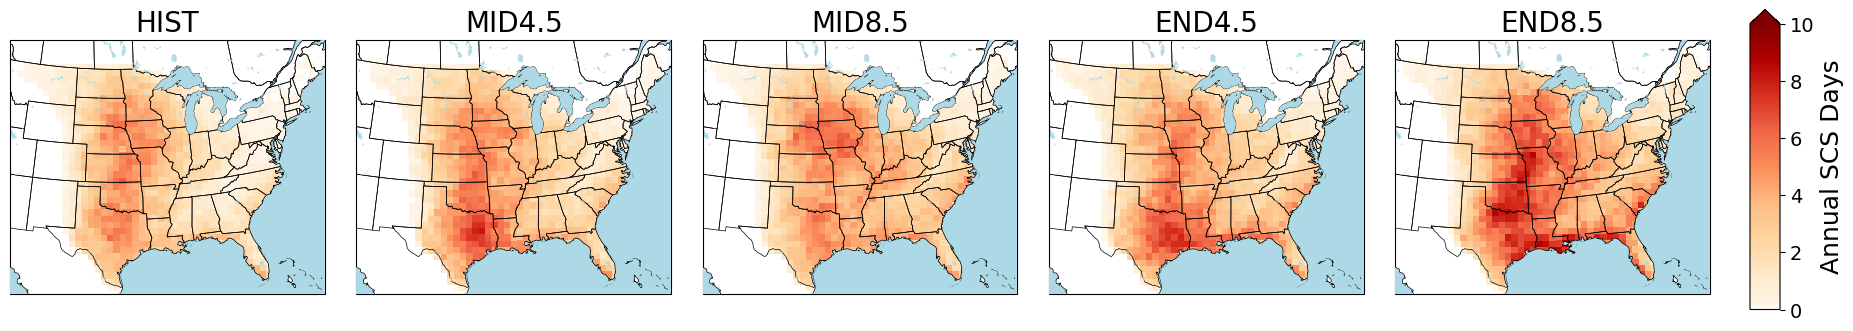

In [24]:
# plot annual climo
fig, axes = plt.subplots(
    nrows=1, ncols=len(epochs), figsize=(20, 5),
    subplot_kw={'projection': ccrs.LambertConformal(central_longitude=-98, central_latitude=35)}
)

vmin, vmax = 0, 10
for j, epoch in enumerate(epochs):
    ax = axes[j]
    da = annual_maps_days_mean[epoch]

    mesh = ax.pcolormesh(
        da['lon'], da['lat'], da,
        transform=ccrs.PlateCarree(), cmap=WtOrRd,
        vmin=vmin, vmax=vmax
    )

    ax.set_extent([-110, -74, 24.5, 50])
    ax.add_feature(cfeature.STATES, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=3)
    ax.add_feature(cfeature.LAKES, facecolor='lightblue')
    ax.set_title(epoch_labels[j], fontsize=20)

cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
cbar = fig.colorbar(mesh, cax=cbar_ax, extend='max')
cbar.set_label('Annual SCS Days', fontsize=18)
cbar.ax.tick_params(labelsize=14)

# fig.suptitle('Annual SCW Day Climatology by Epoch', fontsize=18, y=0.92)
fig.subplots_adjust(left=0.05, right=0.9, top=0.92, bottom=0.05, wspace=0.1)

plt.savefig('../Plots/spatial_days_annual_sig2.png', format='png', dpi=500, bbox_inches='tight')

plt.show()

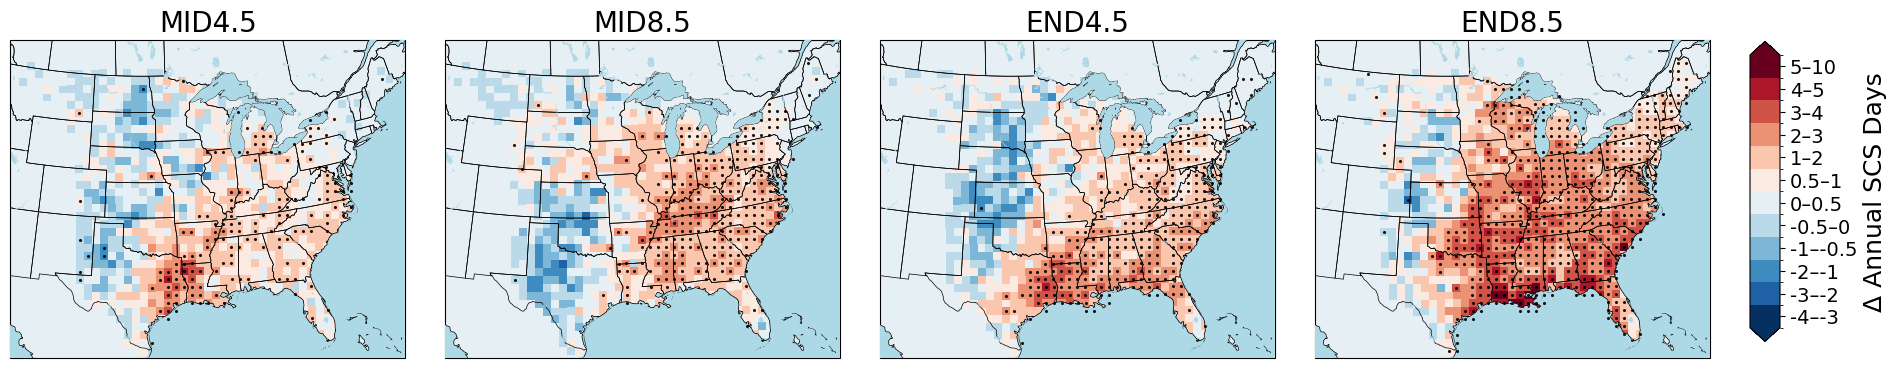

In [53]:
# plot annual delta
fig, axes = plt.subplots(
    nrows=1, ncols=len(future_epochs), figsize=(20, 5),
    subplot_kw={'projection': ccrs.LambertConformal(central_longitude=-98, central_latitude=35)}
)

# for plotting continuous colorbar
# norm = TwoSlopeNorm(vmin=-4, vcenter=0, vmax=5)
# for j, epoch in enumerate(future_epochs):
#     ax = axes[j]
#     da = delta_annual_days_mean[epoch]

#     mesh = ax.pcolormesh(
#         da['lon'], da['lat'], da,
#         transform=ccrs.PlateCarree(), cmap=plt.cm.RdBu_r, norm=norm
#     )

# for plotting discrete bins
bounds = np.array([-4, -3, -2, -1, -0.5, 0, 0.5, 1, 2, 3, 4, 5, 10], dtype=float)
cmap = plt.cm.RdBu_r
cmap_disc = mpl.colormaps[cmap.name].resampled(len(bounds) - 1)
norm = mpl.colors.BoundaryNorm(bounds, cmap_disc.N, clip=True)
mid_ticks = (bounds[:-1] + bounds[1:]) / 2  # midpoint ticks

for j, epoch in enumerate(future_epochs):
    ax = axes[j]
    da = delta_annual_days_mean[epoch]

    mesh = ax.pcolormesh(da['lon'], da['lat'], da, transform=ccrs.PlateCarree(), cmap=cmap_disc, norm=norm)
    
    # per-year annual arrays for HIST and future
    hist_yrs = annual_years_days[ref_epoch].values 
    fut_yrs  = annual_years_days[epoch].values  

    exp = (hist_yrs.shape[0], hist_yrs.shape[1], hist_yrs.shape[2])
    pvals = stats.grid_significance(hist_yrs, fut_yrs, expected_dims=exp)
    sig_mask = np.isfinite(pvals) & (pvals < 0.05)

    add_sig_stippling(ax, da['lon'].values, da['lat'].values, sig_mask)

    ax.set_extent([-110, -74, 24.5, 50])
    ax.add_feature(cfeature.STATES, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=3)
    ax.add_feature(cfeature.LAKES, facecolor='lightblue')
    ax.set_title(epoch_labels[j + 1], fontsize=20)

cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
cbar = fig.colorbar(mesh, cax=cbar_ax, extend='both')
cbar.set_ticks(mid_ticks)
cbar.set_ticklabels([f"{lo:g}–{hi:g}" for lo, hi in zip(bounds[:-1], bounds[1:])])
cbar.set_label('Δ Annual SCS Days', fontsize=18)
cbar.ax.tick_params(labelsize=14)

# fig.suptitle('Annual Δ SCW Days Relative to HIST', fontsize=18, y=0.92)
fig.subplots_adjust(left=0.05, right=0.9, top=0.92, bottom=0.05, wspace=0.1)

plt.savefig('../Plots/spatial_days_annual_delta_sig2.png', format='png', dpi=500, bbox_inches='tight')
plt.show()

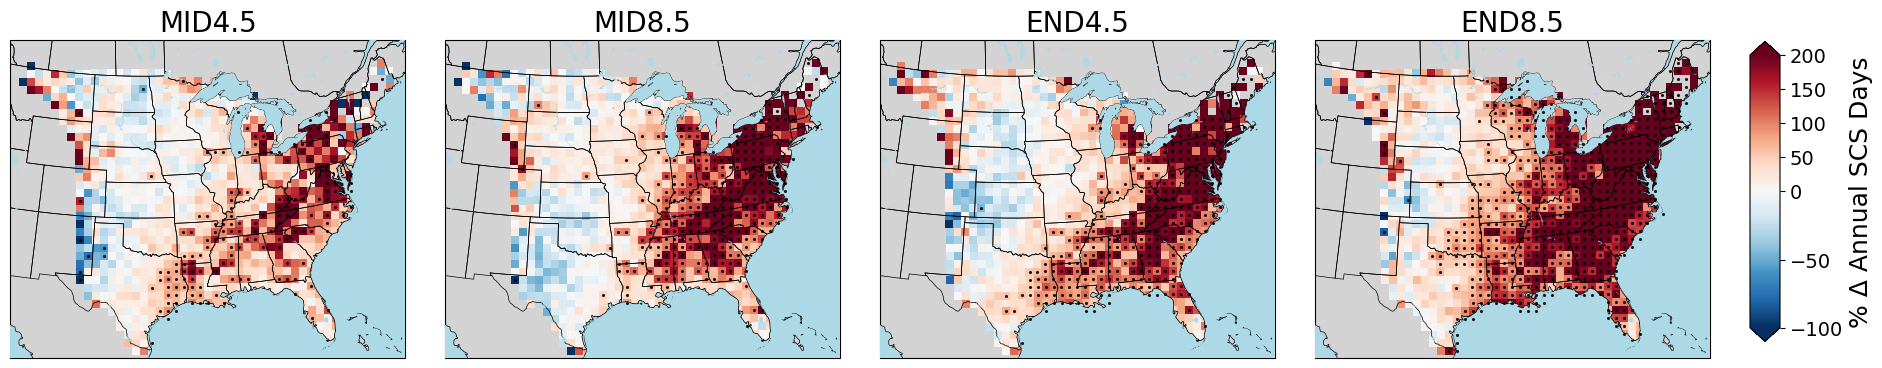

In [44]:
# plot annual percent chg
fig, axes = plt.subplots(
    nrows=1, ncols=len(future_epochs), figsize=(20, 5),
    subplot_kw={'projection': ccrs.LambertConformal(central_longitude=-98, central_latitude=35)}
)

norm_pt_ann = TwoSlopeNorm(vmin=-100, vcenter=0, vmax=200)

for j, epoch in enumerate(future_epochs):
    ax = axes[j]
    da = percent_annual_days_mean[epoch]

    mesh = ax.pcolormesh(
        da['lon'], da['lat'], da,
        transform=ccrs.PlateCarree(), cmap=plt.cm.RdBu_r, norm=norm_pt_ann
    )
    
    # per-year arrays for HIST and future
    hist_yrs = annual_years_days[ref_epoch].values
    fut_yrs  = annual_years_days[epoch].values 

    exp = (hist_yrs.shape[0], hist_yrs.shape[1], hist_yrs.shape[2])
    pvals = stats.grid_significance(hist_yrs, fut_yrs, expected_dims=exp)
    sig_mask = np.isfinite(pvals) & (pvals < 0.05)

    add_sig_stippling(ax, da['lon'].values, da['lat'].values, sig_mask)

    ax.set_extent([-110, -74, 24.5, 50])
    ax.add_feature(cfeature.STATES, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=3)
    ax.add_feature(cfeature.LAKES, facecolor='lightblue')
    ax.set_title(epoch_labels[j + 1], fontsize=20)

cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
cbar = fig.colorbar(mesh, cax=cbar_ax, extend='both')
cbar.set_label('% Δ Annual SCS Days', fontsize=18)
cbar.ax.tick_params(labelsize=14)

# fig.suptitle('Annual % Change in SCW Days Relative to HIST', fontsize=18, y=0.92)
fig.subplots_adjust(left=0.05, right=0.9, top=0.92, bottom=0.05, wspace=0.1)

plt.savefig('../Plots/spatial_days_annual_percent_sig2.png', format='png', dpi=500, bbox_inches='tight')
plt.show()

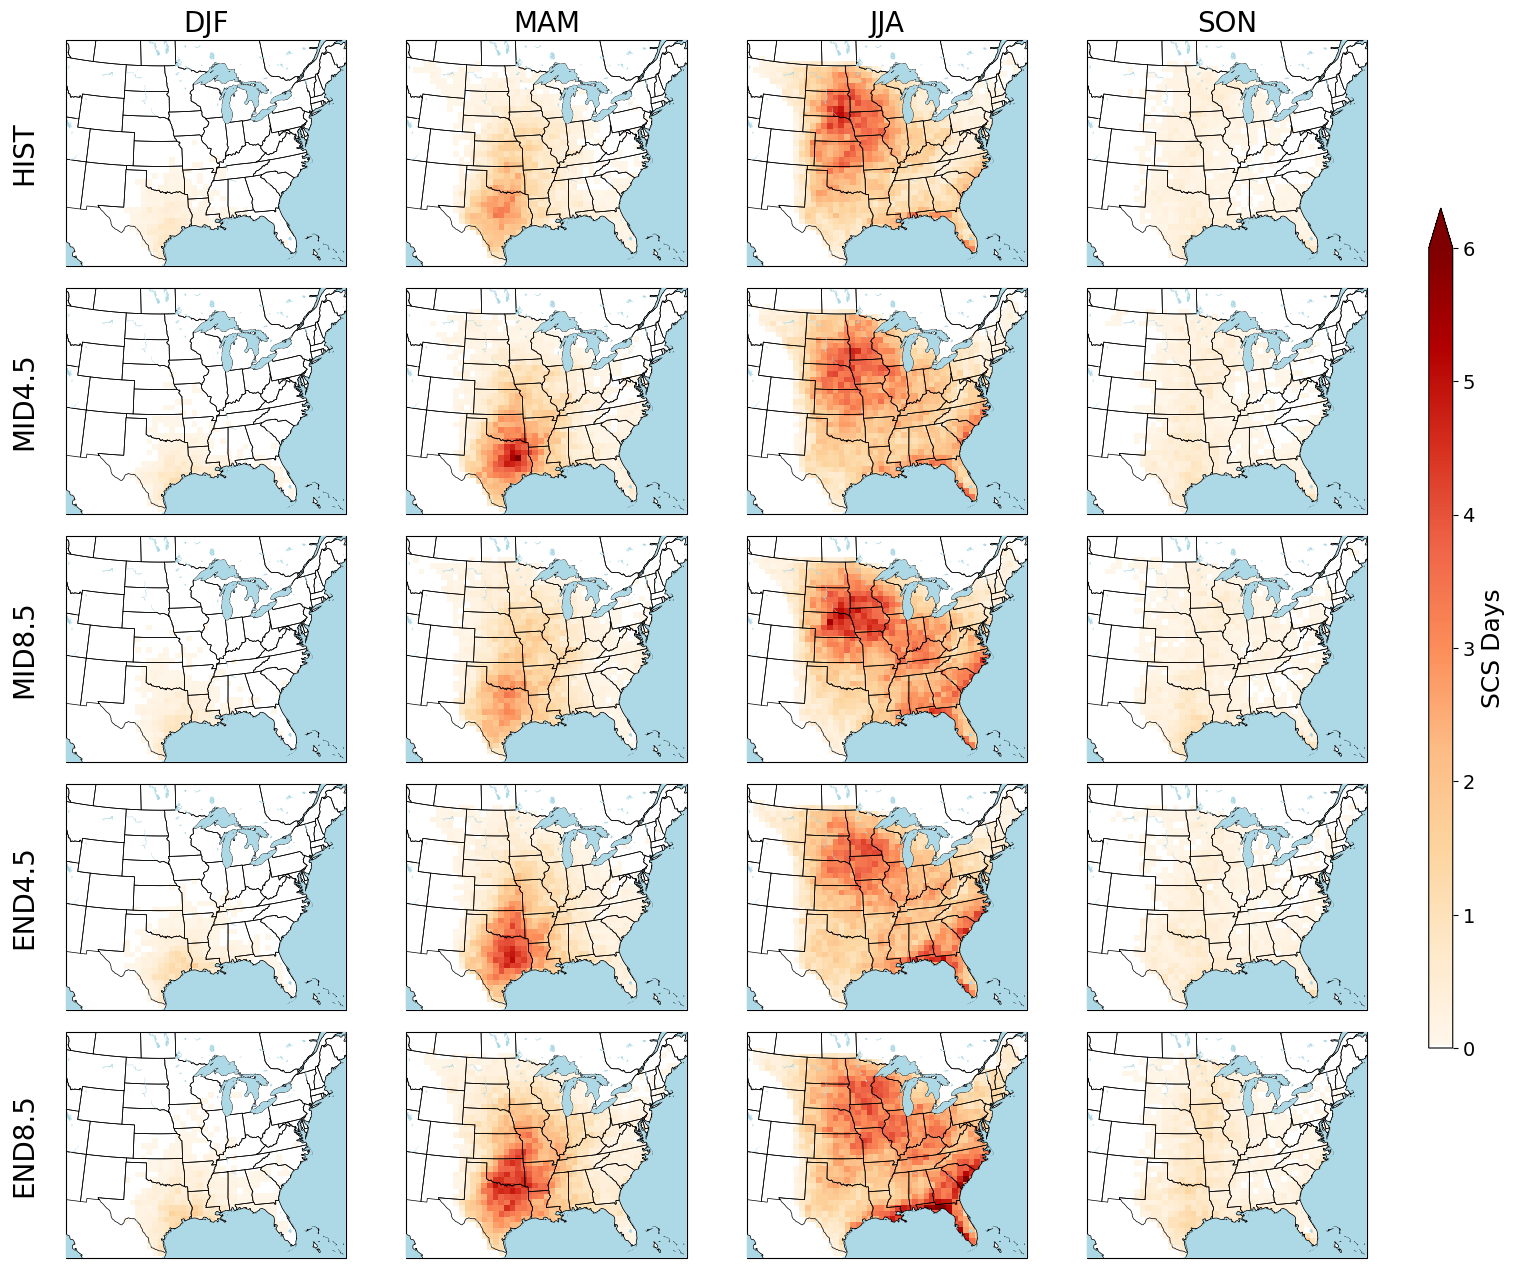

In [43]:
# plot seasonal spatial days (mean per year)
fig, axes = plt.subplots(
    nrows=len(epochs), ncols=len(seasons),
    figsize=(16, 14),
    subplot_kw={'projection': ccrs.LambertConformal(central_longitude=-98, central_latitude=35)}
)

vmin, vmax = 0, 6
# cmap = plt.cm.OrRd

# --- Plot each map ---
for i, epoch in enumerate(epochs):
    for j, season in enumerate(seasons):
        ax = axes[i, j]
        da = seasonal_maps_days_mean[(epoch, season)]

        mesh = ax.pcolormesh(
            da['lon'], da['lat'], da,
            transform=ccrs.PlateCarree(), cmap=WtOrRd,
            vmin=vmin, vmax=vmax
        )

        ax.set_extent([-110, -74, 24.5, 50])
        ax.add_feature(cfeature.STATES, linewidth=0.5)
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.LAND, facecolor='lightgray')
        ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=3)
        ax.add_feature(cfeature.LAKES, facecolor='lightblue')

        if i == 0:
            ax.set_title(season, fontsize=20)
        if j == 0:
            ax.text(-0.1, 0.5, epoch_labels[i], va='center', ha='right', rotation='vertical',
                    transform=ax.transAxes, fontsize=20)
            
# --- Colorbar ---
cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
cbar = fig.colorbar(mesh, cax=cbar_ax, extend='max')
cbar.set_label('SCS Days', fontsize=18)
cbar.ax.tick_params(labelsize=14)

# fig.suptitle('SCW Days Climatology', fontsize=18, y=0.97)
# plt.tight_layout(rect=[0, 0, 0.9, 0.95])
fig.subplots_adjust(left=0.05, right=0.9, top=0.92, bottom=0.05, wspace=0.005, hspace=0.1)

plt.savefig('../Plots/spatial_days_seasonal_sig2.png', format='png', dpi=500, bbox_inches='tight')

plt.show()

In [45]:
# Delta and Percent maps means
delta_maps_days_mean = {}
percent_maps_days_mean = {}
for epoch in future_epochs:
    for season in seasons:
        base = seasonal_maps_days_mean[(ref_epoch, season)]
        fut  = seasonal_maps_days_mean[(epoch, season)]
        d    = fut - base
        pct  = (d / base.where(base > 0)) * 100
        delta_maps_days_mean[(epoch, season)]   = d
        percent_maps_days_mean[(epoch, season)] = pct

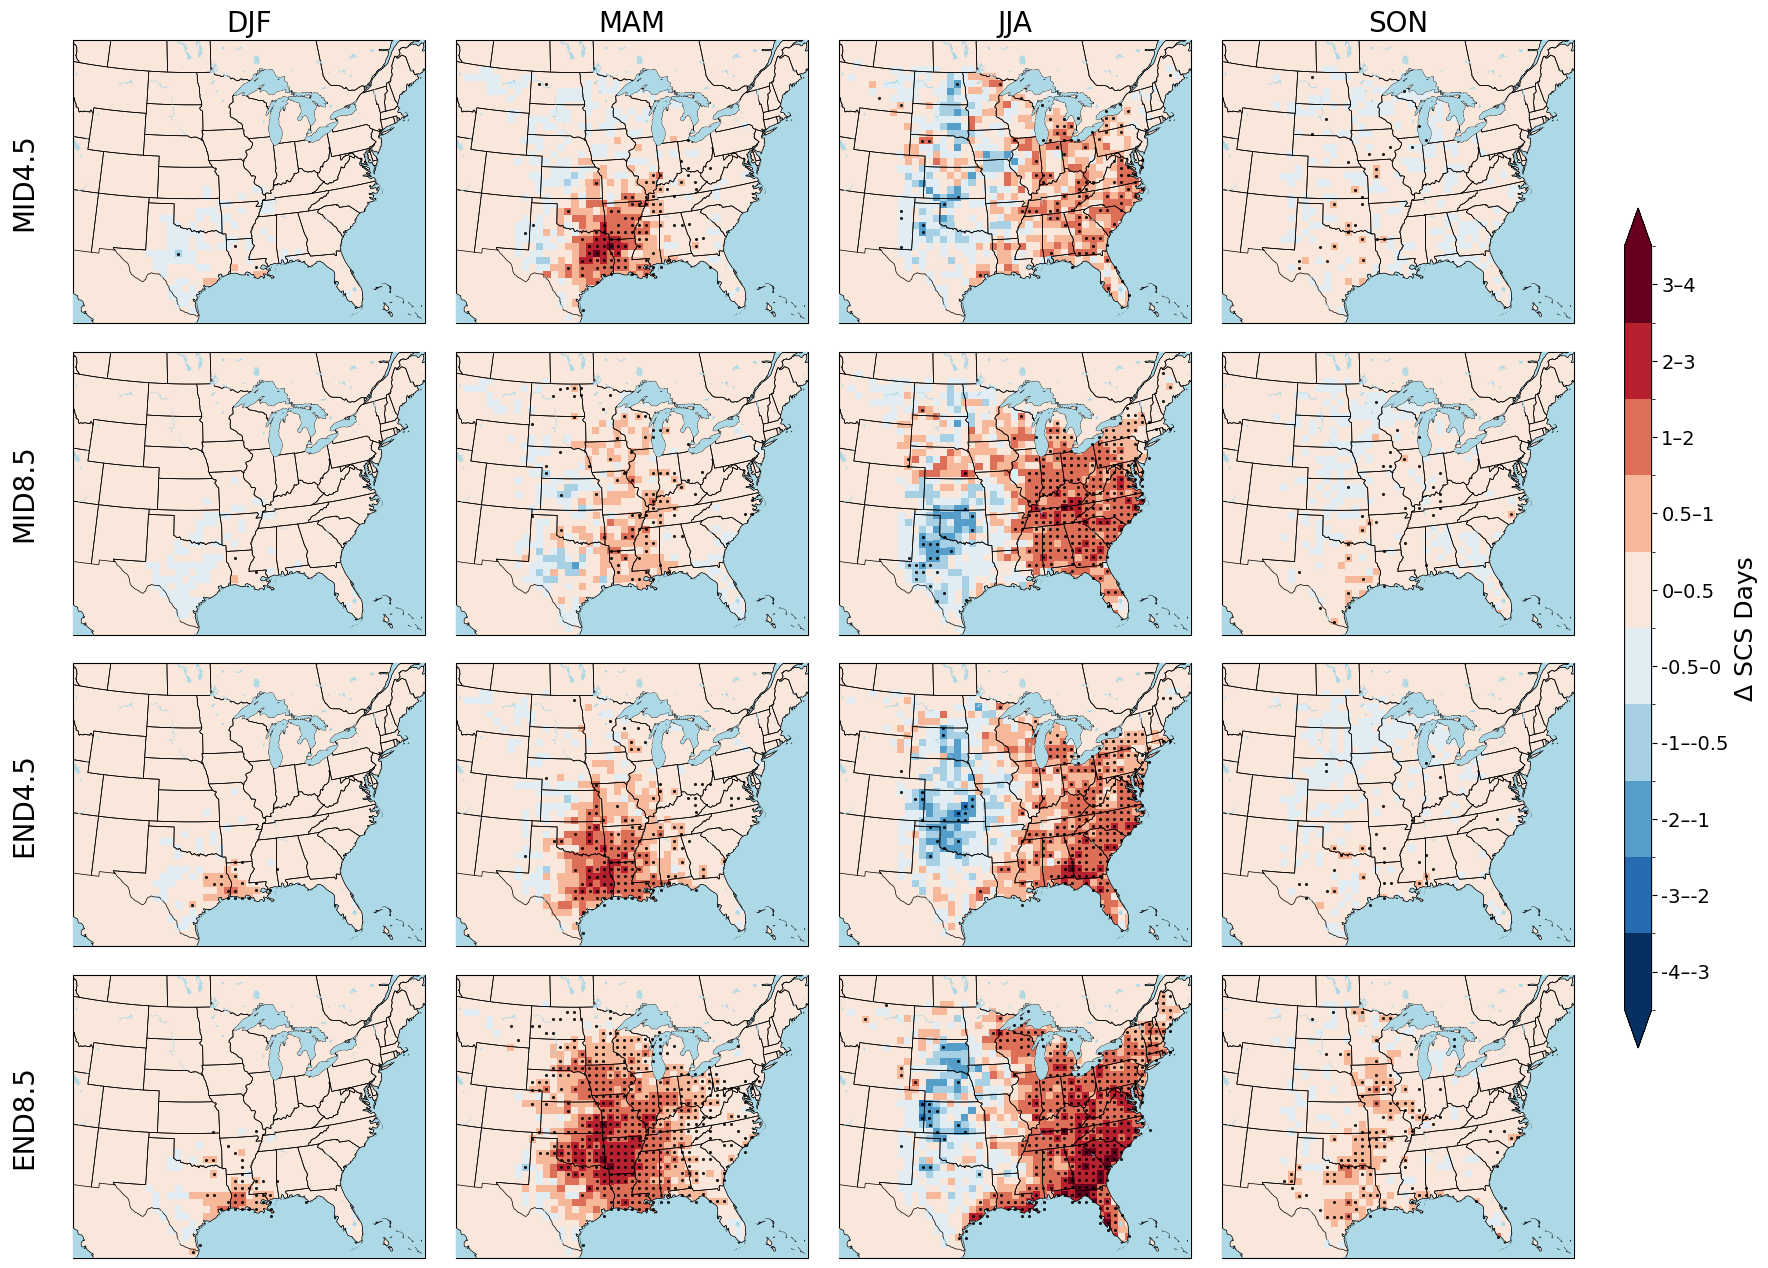

In [54]:
# plot delta days
fig, axes = plt.subplots(
    nrows=len(future_epochs), ncols=len(seasons),
    figsize=(18, 14),
    subplot_kw={'projection': ccrs.LambertConformal(central_longitude=-98, central_latitude=35)}
)

# for linear continuous colormap
# cmap_div = plt.cm.RdBu_r
# # vmin, vmax = -50, 75
# norm_delta = TwoSlopeNorm(vmin=-4, vcenter=0, vmax=4)

# for i, epoch in enumerate(future_epochs):
#     for j, season in enumerate(seasons):
#         ax = axes[i, j]
#         da = delta_maps_days_mean[(epoch, season)]

#         mesh = ax.pcolormesh(
#             da['lon'], da['lat'], da,
#             transform=ccrs.PlateCarree(), cmap=cmap_div,
#             # vmin=vmin, vmax=vmax
#             norm=norm_delta
#         )

# for discrete colormap
bounds = np.array([-4, -3, -2, -1, -0.5, 0, 0.5, 1, 2, 3, 4], dtype=float)
cmap_disc = mpl.colormaps['RdBu_r'].resampled(len(bounds) - 1)
norm = mpl.colors.BoundaryNorm(bounds, cmap_disc.N, clip=True)
mid_ticks = (bounds[:-1] + bounds[1:]) / 2

for i, epoch in enumerate(future_epochs):
    for j, season in enumerate(seasons):
        ax = axes[i, j]
        da = delta_maps_days_mean[(epoch, season)]

        mesh = ax.pcolormesh(da['lon'], da['lat'], da, transform=ccrs.PlateCarree(), cmap=cmap_disc, norm=norm)
        
        # per-year seasonal arrays for HIST and future
        hist_yrs = season_years_days[(ref_epoch, season)].values 
        fut_yrs  = season_years_days[(epoch, season)].values  

        exp = (hist_yrs.shape[0], hist_yrs.shape[1], hist_yrs.shape[2])
        pvals = stats.grid_significance(hist_yrs, fut_yrs, expected_dims=exp)
        sig_mask = np.isfinite(pvals) & (pvals < 0.05)

        add_sig_stippling(ax, da['lon'].values, da['lat'].values, sig_mask)

        ax.set_extent([-110, -74, 24.5, 50])
        ax.add_feature(cfeature.STATES, linewidth=0.5)
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.LAND, facecolor='lightgray')
        ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=3)
        ax.add_feature(cfeature.LAKES, facecolor='lightblue')

        if i == 0:
            ax.set_title(season, fontsize=20)
        if j == 0:
            ax.text(-0.1, 0.5, epoch_labels[i+1], va='center', ha='right', rotation='vertical',
                    transform=ax.transAxes, fontsize=20)

cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
cbar = fig.colorbar(mesh, cax=cbar_ax, extend='both')
cbar.set_label('Δ SCS Days', fontsize=18)
cbar.ax.tick_params(labelsize=14)
cbar.set_ticks(mid_ticks)
cbar.set_ticklabels([f"{lo:g}–{hi:g}" for lo, hi in zip(bounds[:-1], bounds[1:])])

# fig.suptitle('Seasonal Δ SCW Days Relative to HIST', fontsize=18, y=0.92)
fig.subplots_adjust(left=0.05, right=0.9, top=0.92, bottom=0.05, wspace=0.005, hspace=0.1)

plt.savefig('../Plots/spatial_days_seasonal_delta_sig2.png', format='png', dpi=500, bbox_inches='tight')
plt.show()

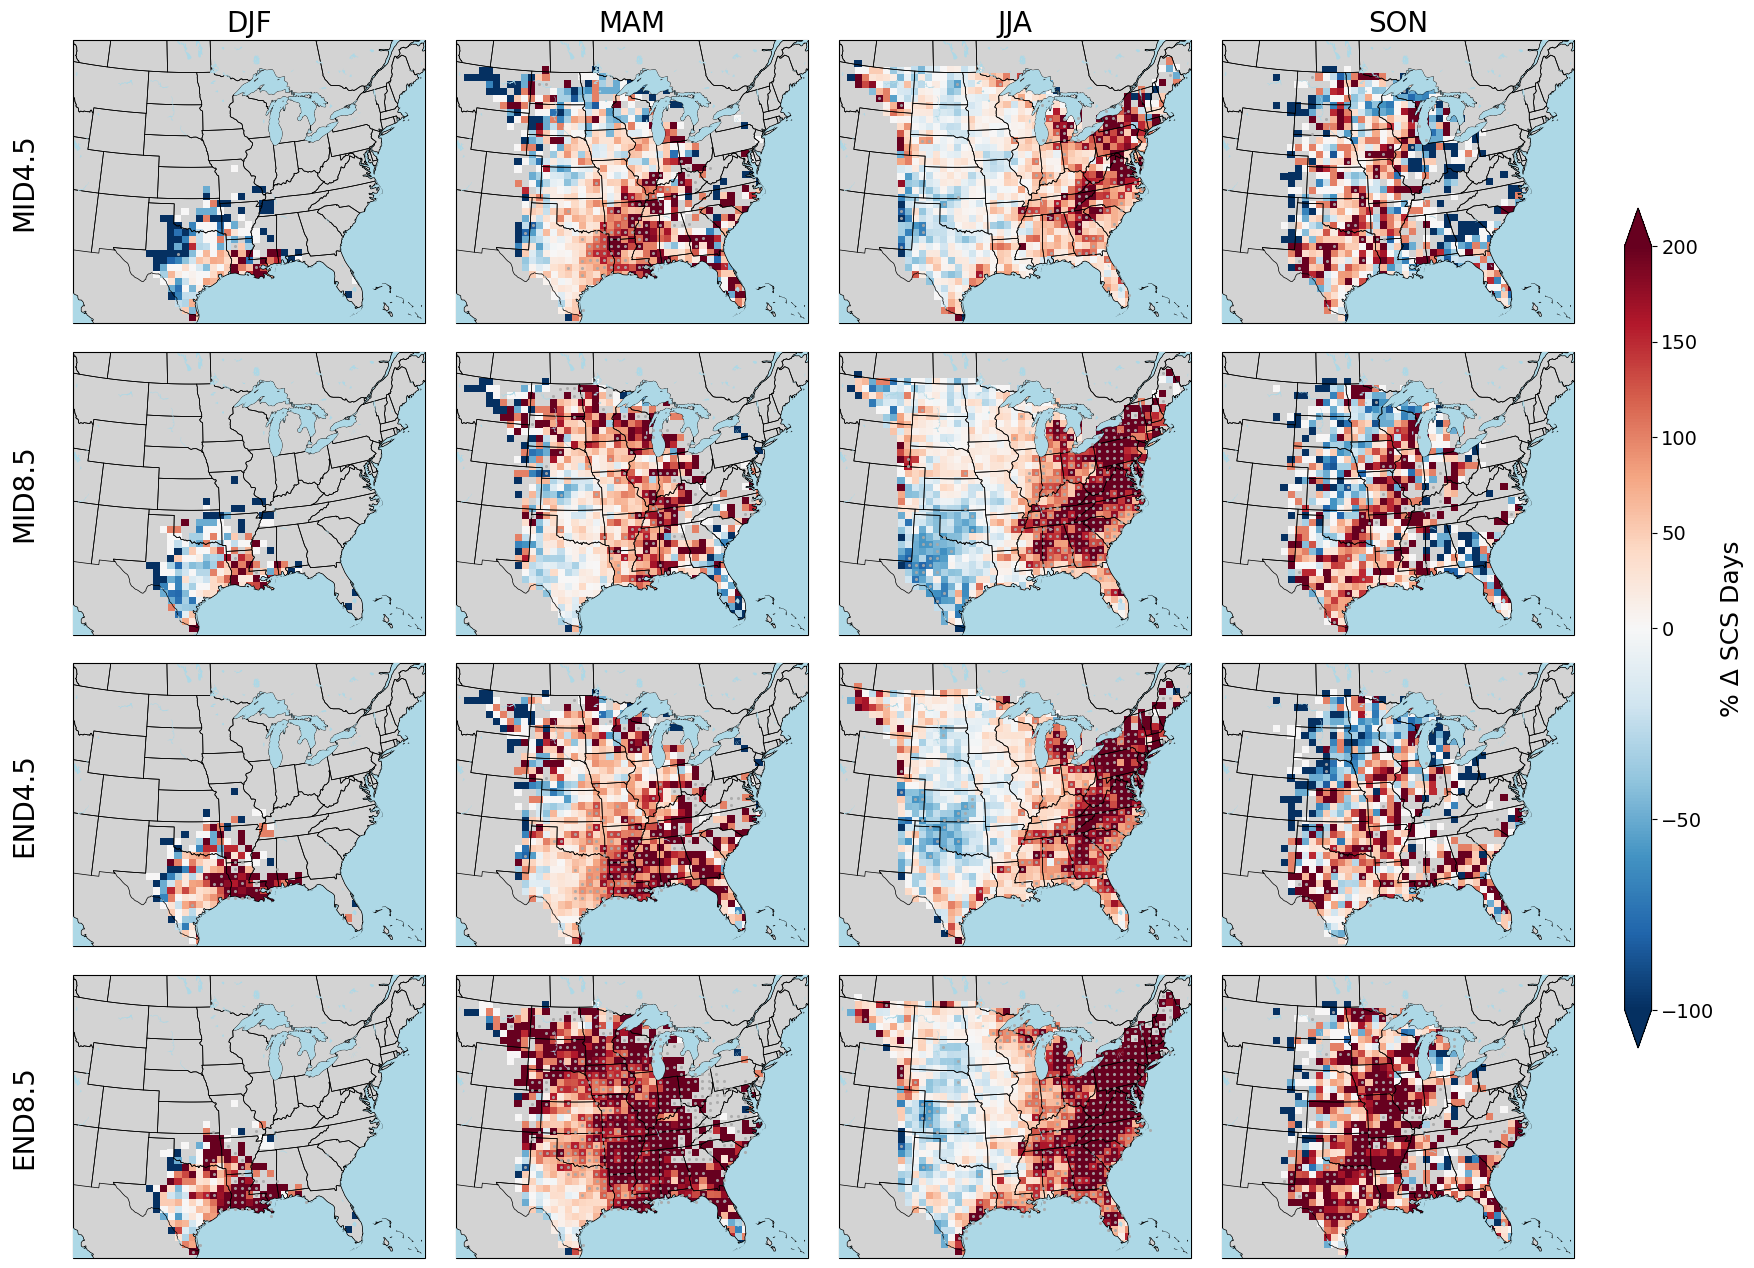

In [50]:
# plot percent chg days
fig, axes = plt.subplots(
    nrows=len(future_epochs), ncols=len(seasons),
    figsize=(18, 14),
    subplot_kw={'projection': ccrs.LambertConformal(central_longitude=-98, central_latitude=35)}
)

norm_percent = TwoSlopeNorm(vmin=-100, vcenter=0, vmax=200)

for i, epoch in enumerate(future_epochs):
    for j, season in enumerate(seasons):
        ax = axes[i, j]
        da = percent_maps_days_mean[(epoch, season)]

        mesh = ax.pcolormesh(
            da['lon'], da['lat'], da,
            transform=ccrs.PlateCarree(), cmap=cmap_div,
            # vmin=vmin, vmax=vmax
            norm=norm_percent
        )
        
        # per-year seasonal arrays for HIST and future
        hist_yrs = season_years_days[(ref_epoch, season)].values 
        fut_yrs  = season_years_days[(epoch, season)].values 

        exp = (hist_yrs.shape[0], hist_yrs.shape[1], hist_yrs.shape[2])
        pvals = stats.grid_significance(hist_yrs, fut_yrs, expected_dims=exp)
        sig_mask = np.isfinite(pvals) & (pvals < 0.05)

        add_sig_stippling(ax, da['lon'].values, da['lat'].values, sig_mask, color='darkgrey')

        ax.set_extent([-110, -74, 24.5, 50])
        ax.add_feature(cfeature.STATES, linewidth=0.5)
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.LAND, facecolor='lightgray')
        ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=3)
        ax.add_feature(cfeature.LAKES, facecolor='lightblue')

        if i == 0:
            ax.set_title(season, fontsize=20)
        if j == 0:
            ax.text(-0.1, 0.5, epoch_labels[i+1], va='center', ha='right', rotation='vertical',
                    transform=ax.transAxes, fontsize=20)

cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
cbar = fig.colorbar(mesh, cax=cbar_ax, extend='both')
cbar.set_label('% Δ SCS Days', fontsize=18)
cbar.ax.tick_params(labelsize=14)

# fig.suptitle('Seasonal % Change in SCW Days Relative to HIST', fontsize=18, y=0.92)
fig.subplots_adjust(left=0.05, right=0.9, top=0.92, bottom=0.05, wspace=0.005, hspace=0.1)

plt.savefig('../Plots/spatial_days_seasonal_percent_sig2.png', format='png', dpi=500, bbox_inches='tight')
plt.show()